# Aula 3 - Leitura e análise de arquivo CSV no Google Colab
## Exemplo de Física: Lei de Ohm

Nesta aula, vamos trabalhar com um arquivo `.csv` contendo **200 pontos experimentais** relacionados à **Lei de Ohm**.

A ideia é ensinar, passo a passo, como:

- importar bibliotecas;
- carregar um arquivo CSV no Colab;
- visualizar os dados;
- entender o significado físico das colunas;
- criar gráficos;
- fazer uma análise simples;
- estimar a resistência elétrica de um resistor.

---

## Contexto físico

A **Lei de Ohm** relaciona a tensão elétrica, a corrente elétrica e a resistência por meio da equação:

$$
V = R \cdot I
$$

Onde:

- $V$ = tensão elétrica (volts);
- $R$ = resistência elétrica (ohms);
- $I$ = corrente elétrica (ampères).

Se o material for **ôhmico**, a relação entre tensão e corrente será **linear**. Isso significa que, ao construir um gráfico de **tensão versus corrente**, devemos obter aproximadamente uma reta.

---

## Caminho do arquivo usado nesta aula

Vamos usar o seguinte caminho no Google Drive:

```python
/content/drive/MyDrive/Colab Notebooks/dados_fisica_lei_ohm_200_pontos.csv
```

In [1]:
# Importação das bibliotecas principais
# pandas -> leitura e manipulação de tabelas
# matplotlib -> construção de gráficos
# numpy -> cálculos numéricos

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Leitura do arquivo CSV

Agora vamos carregar o arquivo com os dados experimentais.

Observe que o caminho já está definido diretamente para facilitar a aula.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Caminho do arquivo no Google Drive
caminho_arquivo = "/content/drive/MyDrive/Colab Notebooks/dados_fisica_lei_ohm_200_pontos.csv"

# Leitura do arquivo CSV
df = pd.read_csv(caminho_arquivo)

# Exibir as 5 primeiras linhas
df.head()

,ponto,corrente_A,tensao_V,resistencia_estimativa_ohm
0,1,0.05,0.7738,15.4770
1,2,0.10,1.1516,11.5161
2,3,0.15,2.0267,13.5113
3,4,0.20,2.9331,14.6653
4,5,0.25,2.9180,11.6722


## Entendendo as colunas da tabela

Este arquivo possui as seguintes colunas:

- **ponto**: número identificador de cada medição;
- **corrente_A**: corrente elétrica medida em ampères;
- **tensao_V**: tensão elétrica medida em volts;
- **resistencia_estimativa_ohm**: valor estimado de resistência calculado como $R = V/I$ para cada ponto.

Essa última coluna já está no arquivo, mas ainda assim vamos recalculá-la depois para mostrar aos alunos como criar novas colunas a partir dos dados.

In [6]:
# Mostrar informações gerais da tabela
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ponto                       200 non-null    int64  
 1   corrente_A                  200 non-null    float64
 2   tensao_V                    200 non-null    float64
 3   resistencia_estimativa_ohm  200 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 6.4 KB


In [7]:
# Mostrar estatísticas descritivas básicas
df.describe()

,ponto,corrente_A,tensao_V,resistencia_estimativa_ohm
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,5.025000,60.285733,12.020440
std,57.879185,2.893959,34.752242,0.383102
min,1.000000,0.050000,0.773800,11.043400
25%,50.750000,2.537500,30.415125,11.946900
50%,100.500000,5.025000,60.011250,11.999350
75%,150.250000,7.512500,90.249850,12.035875
max,200.000000,10.000000,119.600000,15.477000


## Conferindo o tamanho do conjunto de dados

Como prometido, este conjunto de dados possui **200 pontos**.

In [9]:
# Número de linhas e colunas
df.shape

(200, 4)

## Recalculando a resistência elétrica

Mesmo que o arquivo já traga uma estimativa da resistência, é importante ensinar como criar uma nova coluna.

Pela Lei de Ohm:

$$
R = \frac{V}{I}
$$

Vamos criar uma coluna chamada `resistencia_calculada_ohm`.

In [10]:
# Criar uma nova coluna com base na Lei de Ohm
df["resistencia_calculada_ohm"] = df["tensao_V"] / df["corrente_A"]

# Exibir as primeiras linhas para conferir
df.head()

,ponto,corrente_A,tensao_V,resistencia_estimativa_ohm,resistencia_calculada_ohm
0,1,0.05,0.7738,15.4770,15.476000
1,2,0.10,1.1516,11.5161,11.516000
2,3,0.15,2.0267,13.5113,13.511333
3,4,0.20,2.9331,14.6653,14.665500
4,5,0.25,2.9180,11.6722,11.672000


## Valor médio da resistência

Em dados experimentais, os valores ponto a ponto podem variar um pouco por causa de ruídos, erros instrumentais ou flutuações do experimento.

Por isso, um procedimento simples e importante é calcular a **média da resistência**.

In [11]:
# Calcular a resistência média
resistencia_media = df["resistencia_calculada_ohm"].mean()

# Mostrar o resultado
print(f"Resistência média estimada: {resistencia_media:.3f} ohms")

Resistência média estimada: 12.020 ohms


## Gráfico 1 - Corrente ao longo dos pontos

Este primeiro gráfico é apenas para os alunos observarem como os dados estão distribuídos na tabela.

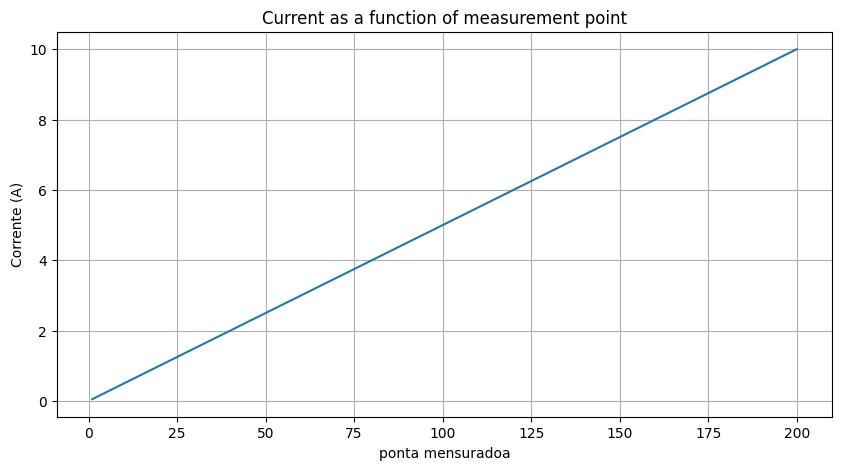

In [13]:
plt.figure(figsize=(10,5))
plt.plot(df["ponto"], df["corrente_A"])
plt.xlabel("ponta mensuradoa")
plt.ylabel("Corrente (A)")
plt.title("Current as a function of measurement point")
plt.grid(True)
plt.show()

## Gráfico 2 - Tensão ao longo dos pontos

Agora observamos a variação da tensão medida.

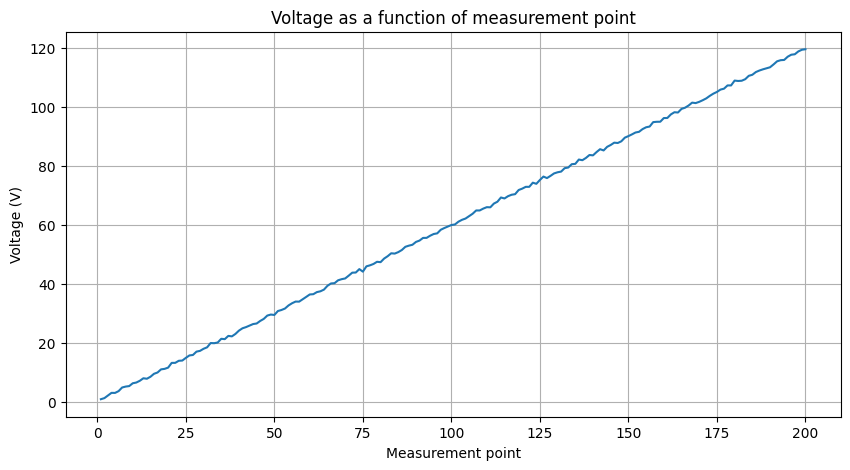

In [14]:
plt.figure(figsize=(10,5))
plt.plot(df["ponto"], df["tensao_V"])
plt.xlabel("Measurement point")
plt.ylabel("Voltage (V)")
plt.title("Voltage as a function of measurement point")
plt.grid(True)
plt.show()

## Gráfico 3 - Tensão versus corrente

Este é o gráfico mais importante da aula.

Se o comportamento for aproximadamente linear, isso indica que o sistema segue a **Lei de Ohm**.

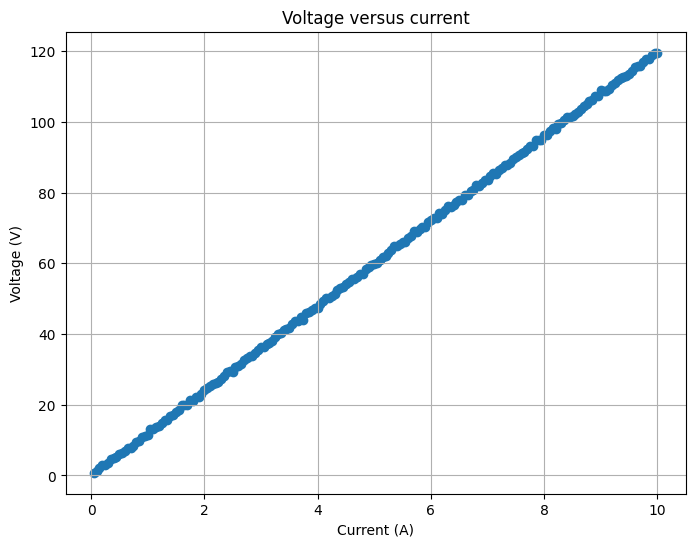

In [15]:
plt.figure(figsize=(8,6))
plt.scatter(df["corrente_A"], df["tensao_V"])
plt.xlabel("Current (A)")
plt.ylabel("Voltage (V)")
plt.title("Voltage versus current")
plt.grid(True)
plt.show()

## Ajuste linear

Para aprofundar a análise, vamos ajustar uma reta aos dados.

Matematicamente, esperamos algo do tipo:

$$
V = aI + b
$$

Onde:

- **a** será aproximadamente a resistência elétrica;
- **b** será um pequeno deslocamento, idealmente próximo de zero.

In [16]:
# Ajuste linear de primeiro grau
coeficientes = np.polyfit(df["corrente_A"], df["tensao_V"], 1)

a = coeficientes[0]
b = coeficientes[1]

print(f"Inclinação da reta (resistência estimada): {a:.4f} ohms")
print(f"Intercepto: {b:.4f} V")

Inclinação da reta (resistência estimada): 12.0080 ohms
Intercepto: -0.0546 V


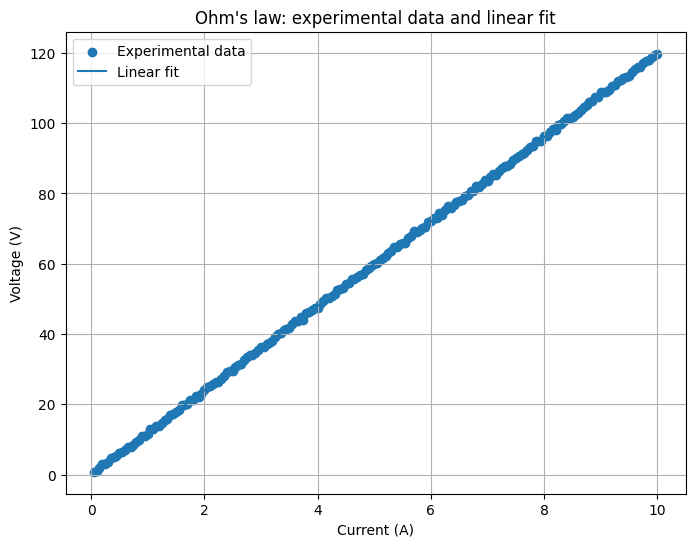

In [17]:
# Gerar valores previstos pela reta ajustada
tensao_ajustada = a * df["corrente_A"] + b

# Gráfico dos dados experimentais com a reta ajustada
plt.figure(figsize=(8,6))
plt.scatter(df["corrente_A"], df["tensao_V"], label="Experimental data")
plt.plot(df["corrente_A"], tensao_ajustada, label="Linear fit")
plt.xlabel("Current (A)")
plt.ylabel("Voltage (V)")
plt.title("Ohm's law: experimental data and linear fit")
plt.grid(True)
plt.legend()
plt.show()

## Interpretação física

Neste ponto da aula, você pode explicar aos alunos que:

1. um resistor ôhmico gera uma relação linear entre tensão e corrente;
2. a inclinação da reta no gráfico $V \times I$ corresponde à resistência;
3. pequenas diferenças entre os pontos e a reta são normais em dados experimentais;
4. a análise com Python ajuda a transformar uma tabela de números em interpretação física.

---

## Comparando dois modos de estimar a resistência

Agora podemos comparar:

- a **média** da coluna $R = V/I$;
- a **inclinação da reta** obtida no ajuste linear.

Esses dois valores tendem a ser próximos.

In [18]:
print(f"Resistência média calculada ponto a ponto: {resistencia_media:.4f} ohms")
print(f"Resistência estimada pelo ajuste linear: {a:.4f} ohms")

Resistência média calculada ponto a ponto: 12.0204 ohms
Resistência estimada pelo ajuste linear: 12.0080 ohms


## Salvando uma cópia com a nova coluna

Também é interessante ensinar como salvar um novo arquivo CSV após o processamento.

In [19]:
# Salvar novo arquivo com a coluna adicional
df.to_csv("/content/drive/MyDrive/Colab Notebooks/dados_fisica_lei_ohm_processado.csv", index=False)

print("Arquivo salvo com sucesso.")

Arquivo salvo com sucesso.


## Conclusão da aula

Nesta aula, aprendemos a:

- carregar um arquivo CSV no Google Colab;
- visualizar e inspecionar dados;
- interpretar variáveis físicas;
- criar uma nova coluna com base em uma equação física;
- construir gráficos;
- fazer um ajuste linear;
- estimar a resistência elétrica de um resistor.

---

## Sugestões para discussão em sala

Você pode perguntar aos alunos:

- O que acontece com o gráfico se o resistor não for ôhmico?
- Por que existe diferença entre dados experimentais e uma reta ideal?
- Qual a vantagem de usar ajuste linear em vez de olhar apenas um ponto?
- Como identificar erros experimentais olhando a tabela ou os gráficos?

---

## Exercício sugerido

Peça aos alunos para:

1. calcular o valor máximo e mínimo da corrente;
2. calcular o valor máximo e mínimo da tensão;
3. construir novamente o gráfico de tensão versus corrente;
4. comparar o valor da resistência média com a resistência obtida pelo ajuste linear;
5. escrever uma conclusão física curta sobre o comportamento do resistor.